# Project Update: Analyzing the Impact of Advertising Spend on Sales Across Different Marketing Channels

## Research Question
How does advertising spend across different marketing channels affect sales, and which channel has the strongest impact?

## Project Overview
This project examines whether advertising spending in different marketing channels can be used to predict sales. The dataset includes advertising budgets for TV, Radio, and Newspaper, along with the corresponding Sales values. The goal is to use regression-based machine learning models to measure how strongly these channels relate to sales and to determine which variable has the greatest predictive importance.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Data Loading

The dataset used in this project contains advertising spending values for three channels, TV, Radio, and Newspaper, as well as the corresponding Sales values. Before building any machine learning model, I first load the dataset and inspect its structure to confirm the variables that will be used for prediction.

In [40]:
df = pd.read_csv("advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [42]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(200, 4)
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


In [44]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print(X.head())
print(y.head())

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


## Exploratory Data Analysis

Before training the model, I explored the dataset visually to understand the relationships between each advertising channel and sales. These plots help show whether the variables appear to have strong or weak relationships with the target and whether the patterns seem approximately linear.

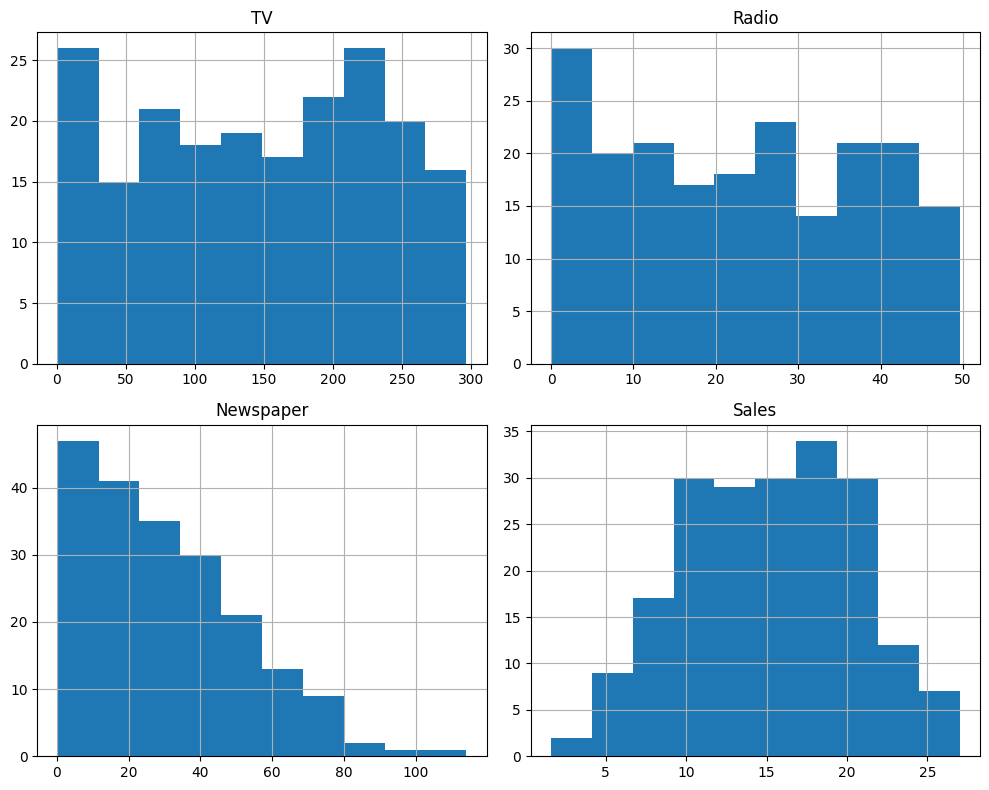

In [47]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

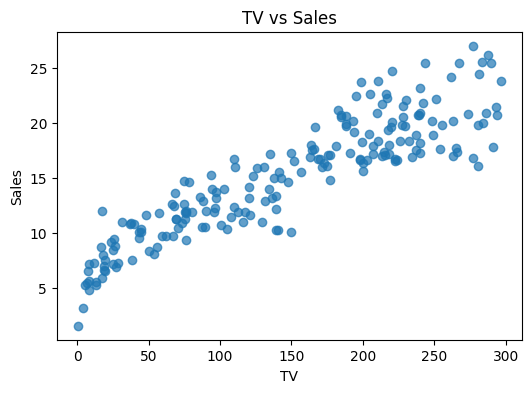

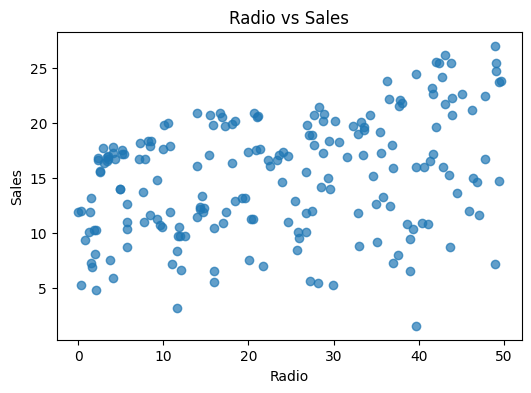

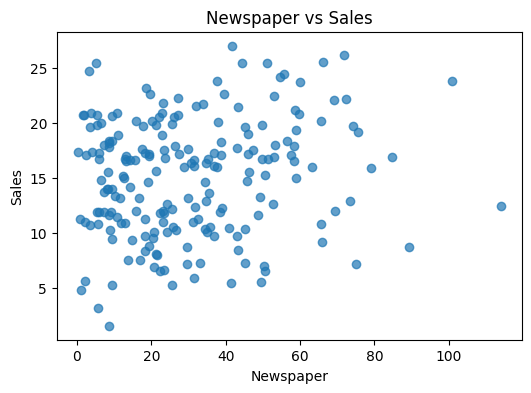

In [49]:
for col in X.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], y, alpha=0.7)
    plt.xlabel(col)
    plt.ylabel("Sales")
    plt.title(f"{col} vs Sales")
    plt.show()

In [51]:
corr = df.corr(numeric_only=True)
print(corr)
print(corr["Sales"].sort_values(ascending=False))

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000
Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64


## Train-Test Split

To evaluate model performance fairly, I split the dataset into training and testing sets. The training set is used to fit the model, and the testing set is used to evaluate how well the model performs on unseen data.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


## Training Model: Linear Regression

Linear regression is an appropriate first model for this project because it directly measures the relationship between advertising spending and sales. It is also useful for interpretation, since the coefficients can show how much each advertising channel contributes to the predicted sales value.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


## Training Model: Linear Regression

Linear regression is an appropriate first model for this project because it directly measures the relationship between advertising spending and sales. It is also useful for interpretation, since the coefficients can show how much each advertising channel contributes to the predicted sales value.

In [60]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MSE:", lr_mse)
print("Linear Regression R^2:", lr_r2)

Linear Regression MSE: 2.9077569102710896
Linear Regression R^2: 0.9059011844150826


## Linear Regression Coefficients

The coefficients from the linear regression model help interpret the relative effect of each advertising channel on sales. A larger positive coefficient suggests that increasing spending in that channel is associated with a larger increase in predicted sales, while controlling for the other variables.

In [63]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
1,Radio,0.100945
0,TV,0.054509
2,Newspaper,0.004337


## Training Model: Random Forest Regressor

In addition to linear regression, I also trained a Random Forest Regressor. This model is useful because it can capture more flexible patterns in the data and may improve predictive performance if the relationship between advertising spend and sales is not perfectly linear.

In [66]:
rf_model = RandomForestRegressor(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R^2:", rf_r2)

Random Forest MSE: 1.3961723562499997
Random Forest R^2: 0.9548180370197178


## Model Comparison

To compare the performance of the two models, I used Mean Squared Error and R² score. Lower MSE indicates smaller average prediction errors, and higher R² indicates that the model explains more of the variation in sales.

In [69]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MSE": [lr_mse, rf_mse],
    "R^2": [lr_r2, rf_r2]
})

results

,Model,MSE,R^2
0,Linear Regression,2.907757,0.905901
1,Random Forest Regressor,1.396172,0.954818


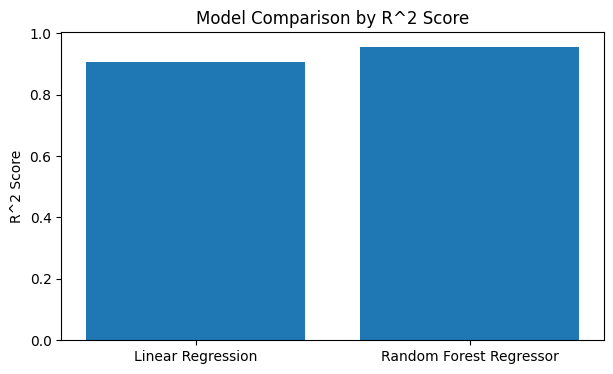

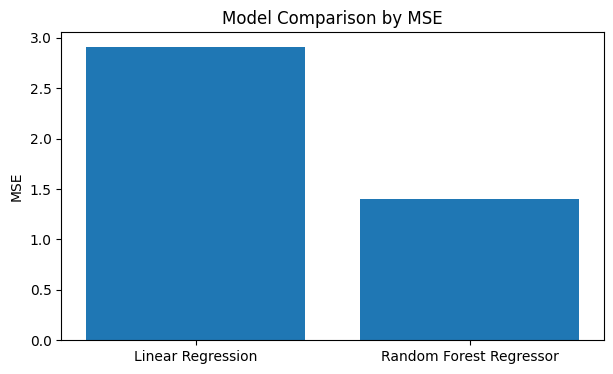

In [71]:
plt.figure(figsize=(7, 4))
plt.bar(results["Model"], results["R^2"])
plt.ylabel("R^2 Score")
plt.title("Model Comparison by R^2 Score")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(results["Model"], results["MSE"])
plt.ylabel("MSE")
plt.title("Model Comparison by MSE")
plt.show()

## Best Model Selection

To continue the analysis, I selected the model with the higher R² score as the stronger predictor. This allows the visualizations below to focus on the model that performs best on the test data.

In [74]:
if rf_r2 >= lr_r2:
    best_model_name = "Random Forest Regressor"
    best_pred = rf_pred
    best_model = rf_model
else:
    best_model_name = "Linear Regression"
    best_pred = lr_pred
    best_model = lr_model

print("Best model:", best_model_name)

Best model: Random Forest Regressor


## Predicted vs Actual Sales

This scatter plot compares the actual sales values with the predicted sales values from the selected model. If the model performs well, the points should fall close to the diagonal reference line, which represents perfect prediction.

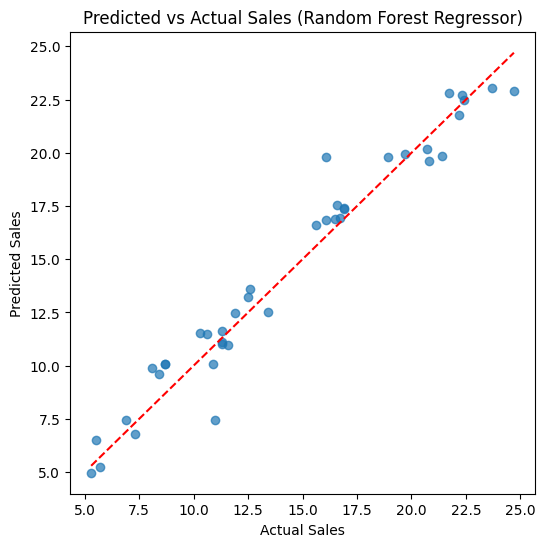

In [77]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Predicted vs Actual Sales ({best_model_name})")
plt.show()

## Residual Error Plot

The residuals represent the difference between the actual sales values and the predicted sales values. This plot helps evaluate whether prediction errors are randomly distributed or whether there is a pattern that suggests the model fits some ranges of the data better than others.

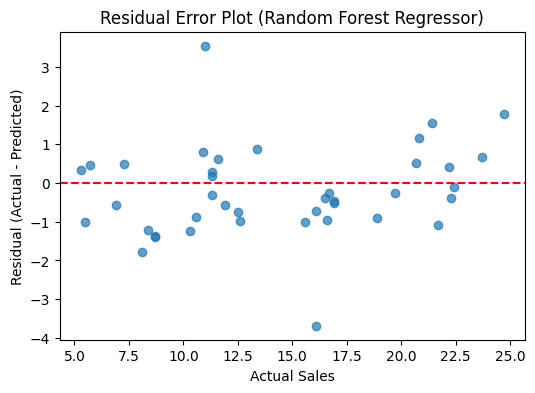

In [96]:
residuals = y_test - best_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_test, residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Actual Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Error Plot ({best_model_name})")
plt.show()

## Distribution of Prediction Errors

A histogram of prediction errors provides another way to evaluate model consistency. If the model performs well, the distribution of errors should be centered near zero, indicating that the predictions are generally close to the actual values.

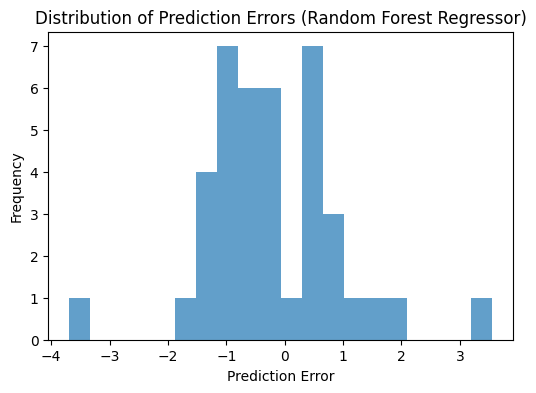

In [99]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, alpha=0.7)
plt.title(f"Distribution of Prediction Errors ({best_model_name})")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

## Feature Importance and Channel Interpretation

A key goal of this project is to determine which advertising channel has the strongest impact on sales. I used model interpretation outputs to examine this question. For linear regression, the coefficients indicate the direction and size of the relationship. For random forest, feature importance scores show which channels contribute most to prediction accuracy.

In [102]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance

,Feature,Importance
0,TV,0.844199
1,Radio,0.136401
2,Newspaper,0.019400


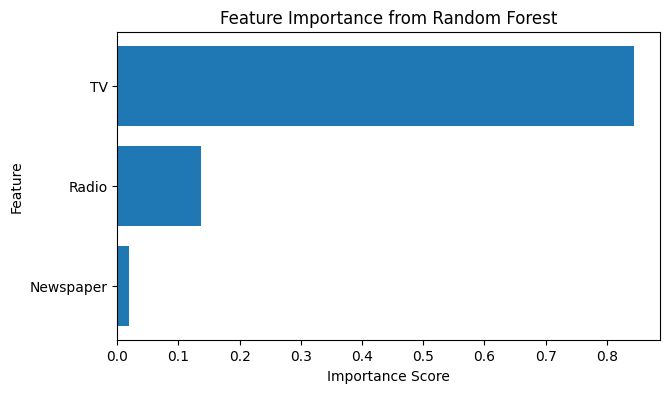

In [104]:
plt.figure(figsize=(7, 4))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance from Random Forest")
plt.gca().invert_yaxis()
plt.show()

## Strongest Advertising Channel

To identify the strongest advertising channel, I compared the largest linear regression coefficient with the highest random forest feature importance score. If the same variable appears strongest in both models, that provides stronger evidence that it has the greatest effect on sales prediction.

In [107]:
top_lr_feature = coef_df.iloc[0]["Feature"]
top_rf_feature = rf_importance.iloc[0]["Feature"]

print("Top feature from Linear Regression:", top_lr_feature)
print("Top feature from Random Forest:", top_rf_feature)

Top feature from Linear Regression: Radio
Top feature from Random Forest: TV


## Current Findings/Results 

The results so far show that advertising spending can be used to predict sales with fairly strong accuracy. The exploratory plots suggest that some channels have a stronger relationship with sales than others, and the model comparison helps determine whether a simple interpretable model or a more flexible machine learning model performs better.

The feature interpretation results are especially important because they connect the machine learning results back to the main research question. Rather than only predicting sales, the project also explains which advertising channel appears to matter most.

This update demonstrates that machine learning methods can be used to analyze the relationship between advertising spend and sales. Linear regression provides a clear and interpretable baseline, while random forest provides a more flexible machine learning comparison.

In the next stage of the project, I plan to expand the discussion of model interpretation, compare the channels more carefully, and explain how these findings could help businesses make more informed budget allocation decisions.